
# Image verification and reliability analysis

This notebook studies whether our image quality metrics correspond to downstream reliability under controlled degradation.

The analysis contains:
1. Baseline texture statistics vs. spectral cutoff
3. Segmentation proxy tests
5. Multi-metric validation under blur and additive noise



# Import

In [1]:

import sys
import os
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from scipy import ndimage as ndi
from scipy import stats
from scipy.ndimage import gaussian_filter, gaussian_filter1d
from scipy.signal.windows import hann
from scipy.stats import entropy as scipy_entropy, pearsonr, spearmanr

from skimage.feature import graycomatrix, graycoprops
from skimage.filters import threshold_otsu
from skimage.measure import label
from skimage.morphology import remove_small_objects


In [ ]:
if os.path.exists("data/"):
    base = "data/patch_samples"
else:
    base = "sample_patches"

## Quality metris

In [2]:
def radial_profile(power):
    h, w = power.shape
    cy, cx = h//2, w//2

    y, x = np.indices((h, w))
    r = np.sqrt((x-cx)**2 + (y-cy)**2)

    r_int = r.astype(int)

    tbin = np.bincount(r_int.ravel(), power.ravel())
    nr = np.bincount(r_int.ravel())

    radial = tbin / np.maximum(nr, 1)

    r_vals = np.arange(len(radial))

    r_norm = r_vals / r.max()

    return r_norm, radial

In [3]:
def effective_resolution_cutoff(patch,
                                detrend_sigma=12,
                                r_min_frac=0.05,
                                tail_frac=0.85):

    patch = patch.astype(np.float32)
    background = gaussian_filter(patch, detrend_sigma)
    g = patch - background

    wy = hann(patch.shape[0])
    wx = hann(patch.shape[1])
    window = np.outer(wy, wx)
    g *= window

    F = np.fft.fftshift(np.fft.fft2(g))
    P = np.abs(F)**2

    r, prof = radial_profile(P)
    n = len(prof)

    tail_start = int(tail_frac * n)
    N0 = np.median(prof[tail_start:])

    prof_corr = np.maximum(prof - N0, 0)
    prof_corr = gaussian_filter1d(prof_corr, 2)

    start = int(r_min_frac * n)
    threshold = 0.05 * prof_corr[start:].max()

    idx = np.where(prof_corr > threshold)[0]
    idx = idx[idx >= start]

    if len(idx) == 0:
        fc = 0
    else:
        fc = r[idx.max()]

    return fc, r, prof, prof_corr

# Texture features (Same ones as in patch quality reliability analysis)

In [ ]:
groups = ["spatial_high", "spatial_low", "spectral_high", "spectral_low"]


def local_variance(img):
    return np.var(img.astype(np.float32))

def shannon_entropy_simple(img, bins=256):
    hist, _ = np.histogram(img.ravel(), bins=bins, range=(0, 256), density=True)
    hist = hist[hist > 0]
    return scipy_entropy(hist, base=2)

def glcm_features(img):
    img_q = (img.astype(np.float32) / 32).astype(np.uint8)
    glcm = graycomatrix(
        img_q,
        distances=[1],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=8,
        symmetric=True,
        normed=True
    )
    contrast = graycoprops(glcm, "contrast").mean()
    homogeneity = graycoprops(glcm, "homogeneity").mean()
    energy = graycoprops(glcm, "energy").mean()
    return contrast, homogeneity, energy

rows = []

for g in groups:
    path = os.path.join(base, g)
    for fname in os.listdir(path):
        if not fname.endswith(".png"):
            continue

        patch = np.array(Image.open(os.path.join(path, fname)).convert("L"))
        fc, _, _, _ = effective_resolution_cutoff(patch)

        var_ = local_variance(patch)
        ent_ = shannon_entropy_simple(patch)
        contrast, homogeneity, energy = glcm_features(patch)

        rows.append({
            "group": g,
            "file": fname,
            "fc": fc,
            "variance": var_,
            "entropy": ent_,
            "glcm_contrast": contrast,
            "glcm_homogeneity": homogeneity,
            "glcm_energy": energy,
        })

df = pd.DataFrame(rows)
df.head()

,group,file,fc,variance,entropy,glcm_contrast,glcm_homogeneity,glcm_energy
0,spatial_high,patch_0090913_r21888_c9600.png,0.254116,1946.094482,7.355080,0.735845,0.731383,0.285941
1,spatial_high,patch_0004567_r4736_c81408.png,0.254116,2600.326904,7.538911,0.709948,0.741928,0.267902
2,spatial_high,patch_0004566_r4736_c81280.png,0.193350,2141.515381,7.365840,0.703150,0.740550,0.292158
3,spatial_high,patch_0004213_r4608_c81024.png,0.165728,2052.263672,7.336088,0.697129,0.738565,0.291493
4,spatial_high,patch_0091720_r22016_c9600.png,0.220971,2276.108643,7.455795,0.712754,0.739222,0.269811



# 1. Baseline texture statistics vs. spectral cutoff

This section computes patch descriptors and checks how they relate to the estimated spectral cutoff frequency `fc`.


In [5]:
features = ["variance", "entropy", "glcm_contrast", "glcm_homogeneity", "glcm_energy"]

for feat in features:
    corr = df["fc"].corr(df[feat])
    print(f"{feat}: corr with fc = {corr:.3f}")

variance: corr with fc = -0.570
entropy: corr with fc = -0.515
glcm_contrast: corr with fc = -0.312
glcm_homogeneity: corr with fc = 0.321
glcm_energy: corr with fc = 0.441


In [6]:
df["fc_bin"] = pd.qcut(df["fc"], q=3, labels=["low_fc", "mid_fc", "high_fc"])

summary = df.groupby("fc_bin")[features].agg(["mean", "std"])
summary

/tmp/ipykernel_25326/1356288604.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("fc_bin")[features].agg(["mean", "std"])


variance                entropy           glcm_contrast            \
                mean          std      mean       std          mean       std   
fc_bin                                                                          
low_fc   2515.301270  2122.661377  5.018292  1.954564      0.170415  0.241397   
mid_fc   1517.371094  1141.935913  5.409275  3.129620      0.479066  0.366350   
high_fc    56.794376    61.750896  1.816438  0.506681      0.009700  0.010290   

        glcm_homogeneity           glcm_energy            
                    mean       std        mean       std  
fc_bin                                                    
low_fc          0.933567  0.089527    0.712971  0.248679  
mid_fc          0.824737  0.134011    0.516586  0.368291  
high_fc         0.996205  0.004703    0.991641  0.009540

In [7]:
cv_summary = {}
for feat in features:
    grp = df.groupby("fc_bin")[feat]
    cv_summary[feat] = (grp.std() / (grp.mean().abs() + 1e-8)).to_dict()

cv_summary

/tmp/ipykernel_25326/1409371104.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df.groupby("fc_bin")[feat]
/tmp/ipykernel_25326/1409371104.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df.groupby("fc_bin")[feat]


{'variance': {'low_fc': 0.8438994288444519,
  'mid_fc': 0.7525752186775208,
  'high_fc': 1.0872713327407837},
 'entropy': {'low_fc': 0.3894878068645777,
  'mid_fc': 0.5785655441409492,
  'high_fc': 0.2789420648178056},
 'glcm_contrast': {'low_fc': 1.416524960285159,
  'mid_fc': 0.7647171844167888,
  'high_fc': 1.0607656018020888},
 'glcm_homogeneity': {'low_fc': 0.09589724399616388,
  'mid_fc': 0.16248916597308727,
  'high_fc': 0.004720682647322302},
 'glcm_energy': {'low_fc': 0.34879329716418733,
  'mid_fc': 0.7129328706267376,
  'high_fc': 0.009620043237121333}}

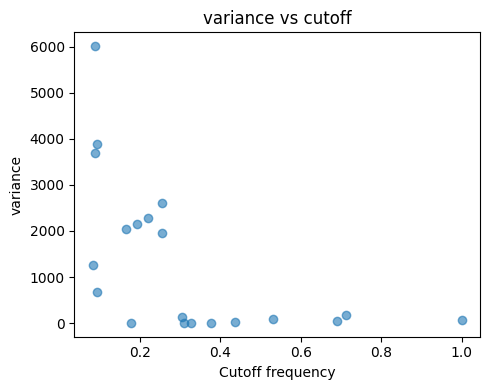

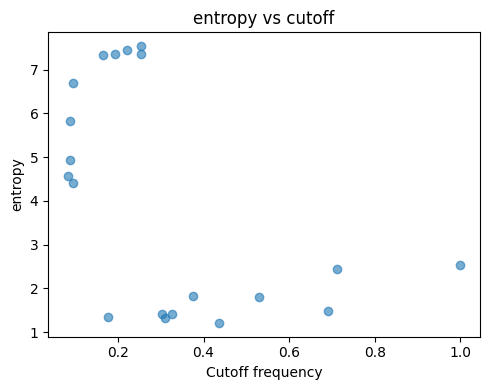

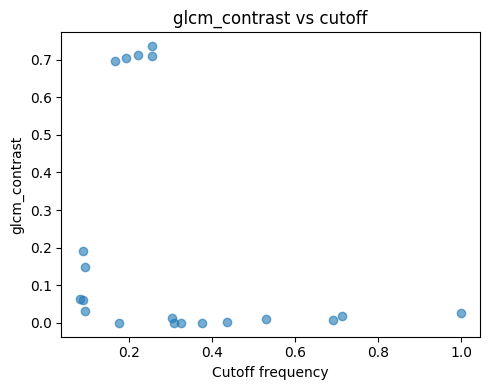

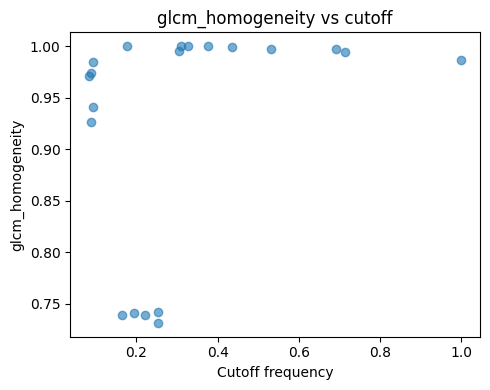

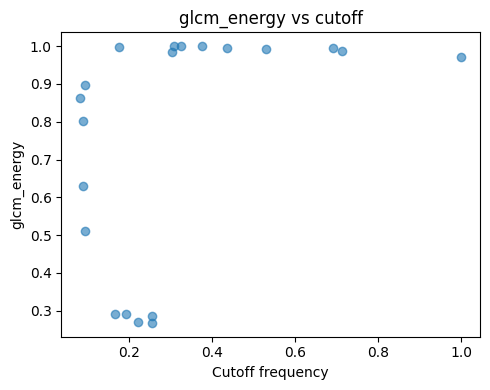

In [8]:
import matplotlib.pyplot as plt

for feat in features:
    plt.figure(figsize=(5,4))
    plt.scatter(df["fc"], df[feat], alpha=0.6)
    plt.xlabel("Cutoff frequency")
    plt.ylabel(feat)
    plt.title(f"{feat} vs cutoff")
    plt.tight_layout()
    plt.show()


# 2. Segmentation proxy tests

To connect image quality to downstream utility, we use a lightweight segmentation/counting proxy. The goal is not to build the best segmenter, but to define a consistent downstream task whose stability can be measured after degradation.


In [9]:

def naive_segment_count(img, blur_sigma=0.0, min_size=6, dark_objects=True):
    x = img.astype(np.float32)

    if blur_sigma > 0:
        x = gaussian_filter(x, blur_sigma)

    thr = threshold_otsu(x)

    if dark_objects:
        mask = x < thr
    else:
        mask = x > thr

    mask = remove_small_objects(mask, min_size=min_size)

    lbl = label(mask)
    count = lbl.max()
    frac = mask.mean()

    return count, frac, mask

### Sensitivity of the segmentation proxy across blur settings

In [10]:
blur_levels = [0, 1, 2, 3]
rows_seg = []

for g in groups:
    path = os.path.join(base, g)
    for fname in os.listdir(path):
        if not fname.endswith(".png"):
            continue

        patch = np.array(Image.open(os.path.join(path, fname)).convert("L"))
        fc, _, _, _ = effective_resolution_cutoff(patch)

        counts = []
        fracs = []

        for s in blur_levels:
            cnt, frac, _ = naive_segment_count(patch, blur_sigma=s, min_size=6, dark_objects=True)
            counts.append(cnt)
            fracs.append(frac)

        rows_seg.append({
            "group": g,
            "file": fname,
            "fc": fc,
            "count_mean": np.mean(counts),
            "count_std": np.std(counts),
            "count_range": np.max(counts) - np.min(counts),
            "count_cv": np.std(counts) / (np.mean(counts) + 1e-8),
            "frac_mean": np.mean(fracs),
            "frac_std": np.std(fracs),
            "counts": counts,
        })

df_seg = pd.DataFrame(rows_seg)
df_seg.head()

,group,file,fc,count_mean,count_std,count_range,count_cv,frac_mean,frac_std,counts
0,spatial_high,patch_0090913_r21888_c9600.png,0.254116,99.25,65.001442,167,0.654926,0.378471,0.051857,"[194, 123, 53, 27]"
1,spatial_high,patch_0004567_r4736_c81408.png,0.254116,58.75,37.638909,97,0.640662,0.381809,0.027509,"[115, 70, 32, 18]"
2,spatial_high,patch_0004566_r4736_c81280.png,0.193350,81.00,47.801674,124,0.590144,0.286854,0.016271,"[154, 92, 48, 30]"
3,spatial_high,patch_0004213_r4608_c81024.png,0.165728,77.50,37.366429,97,0.482147,0.295300,0.011988,"[136, 83, 52, 39]"
4,spatial_high,patch_0091720_r22016_c9600.png,0.220971,47.00,39.629534,100,0.843182,0.536659,0.109758,"[107, 58, 16, 7]"


In [11]:
for feat in ["count_std", "count_range", "count_cv", "frac_std"]:
    corr = df_seg["fc"].corr(df_seg[feat])
    print(f"{feat}: corr with fc = {corr:.3f}")

count_std: corr with fc = 0.506
count_range: corr with fc = 0.490
count_cv: corr with fc = 0.240
frac_std: corr with fc = 0.169


In [12]:
df_seg["fc_bin"] = pd.qcut(df_seg["fc"], q=3, labels=["low_fc", "mid_fc", "high_fc"])

df_seg.groupby("fc_bin")[["count_std", "count_range", "count_cv", "frac_std"]].agg(["mean", "std"])

/tmp/ipykernel_25326/11264486.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_seg.groupby("fc_bin")[["count_std", "count_range", "count_cv", "frac_std"]].agg(["mean", "std"])


count_std            count_range              count_cv            \
              mean        std        mean         std      mean       std   
fc_bin                                                                      
low_fc    5.930073  13.871972   15.285714   36.058814  0.273307  0.150507   
mid_fc   42.816950  24.073077  111.666667   64.217339  0.579361  0.182804   
high_fc  48.919744  87.438620  119.142857  211.495807  0.317825  0.538224   

         frac_std            
             mean       std  
fc_bin                       
low_fc   0.004575  0.004267  
mid_fc   0.042103  0.037970  
high_fc  0.018460  0.031205

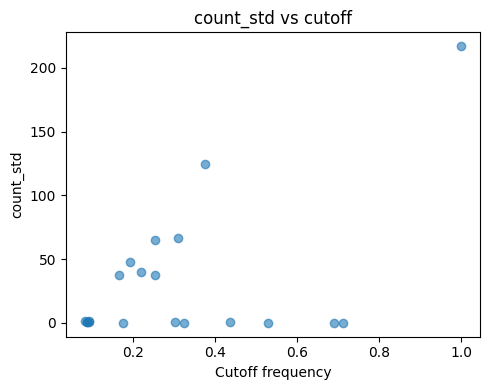

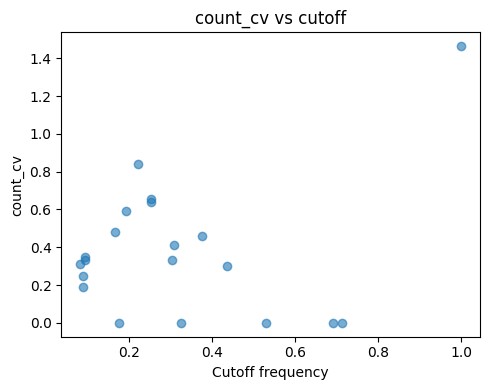

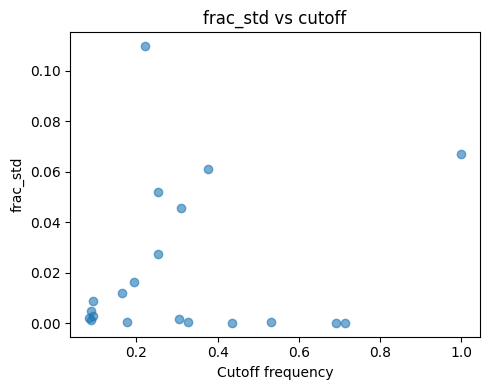

In [13]:
for feat in ["count_std", "count_cv", "frac_std"]:
    plt.figure(figsize=(5,4))
    plt.scatter(df_seg["fc"], df_seg[feat], alpha=0.6)
    plt.xlabel("Cutoff frequency")
    plt.ylabel(feat)
    plt.title(f"{feat} vs cutoff")
    plt.tight_layout()
    plt.show()


## Blur-based verification experiments

Here, each original patch is blurred at several levels. We then compare the degraded result with the original segmentation output using agreement metrics such as count retention and mask IoU.


In [14]:
def mask_iou(a, b):
    a = a.astype(bool)
    b = b.astype(bool)
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return inter / (union + 1e-8)

blur_levels = [0, 0.5, 1, 2, 3]
rows_verif = []

for g in groups:
    path = os.path.join(base, g)
    for fname in os.listdir(path):
        if not fname.endswith(".png"):
            continue

        patch = np.array(Image.open(os.path.join(path, fname)).convert("L"))

        # baseline
        fc0, _, _, _ = effective_resolution_cutoff(patch)
        cnt0, frac0, mask0 = naive_segment_count(
            patch, blur_sigma=0.0, min_size=6, dark_objects=True
        )

        for s in blur_levels:
            if s > 0:
                patch_blur = gaussian_filter(patch.astype(np.float32), s)
            else:
                patch_blur = patch.astype(np.float32)

            fc_s, _, _, _ = effective_resolution_cutoff(patch_blur)
            cnt_s, frac_s, mask_s = naive_segment_count(
                patch_blur, blur_sigma=0.0, min_size=6, dark_objects=True
            )

            rows_verif.append({
                "group": g,
                "file": fname,
                "blur_sigma": s,
                "fc": fc_s,
                "fc_drop": fc0 - fc_s,
                "fc_ratio": fc_s / (fc0 + 1e-8),
                "count": cnt_s,
                "count0": cnt0,
                "count_diff": cnt_s - cnt0,
                "count_abs_diff": abs(cnt_s - cnt0),
                "count_retention": cnt_s / (cnt0 + 1e-8),
                "frac": frac_s,
                "frac0": frac0,
                "frac_abs_diff": abs(frac_s - frac0),
                "mask_iou": mask_iou(mask0, mask_s),
            })

df_verif = pd.DataFrame(rows_verif)
df_verif.head()

,group,file,blur_sigma,fc,fc_drop,fc_ratio,count,count0,count_diff,count_abs_diff,count_retention,frac,frac0,frac_abs_diff,mask_iou
0,spatial_high,patch_0090913_r21888_c9600.png,0.0,0.254116,0.000000,1.000000,194,194,0,0,1.000000,0.317139,0.317139,0.000000,1.000000
1,spatial_high,patch_0090913_r21888_c9600.png,0.5,0.232019,0.022097,0.913043,179,194,-15,15,0.922680,0.328140,0.317139,0.011002,0.926255
2,spatial_high,patch_0090913_r21888_c9600.png,1.0,0.193350,0.060767,0.760870,123,194,-71,71,0.634021,0.346588,0.317139,0.029449,0.801234
3,spatial_high,patch_0090913_r21888_c9600.png,2.0,0.143631,0.110485,0.565217,53,194,-141,141,0.273196,0.396500,0.317139,0.079361,0.662425
4,spatial_high,patch_0090913_r21888_c9600.png,3.0,0.116010,0.138107,0.456522,27,194,-167,167,0.139175,0.453659,0.317139,0.136520,0.582352


### Does blur reduce the estimated cutoff frequency?

In [15]:
df_verif.groupby("blur_sigma")["fc"].agg(["mean", "std"])

,mean,std
blur_sigma,,
0.0,0.319855,0.247046
0.5,0.280357,0.177429
1.0,0.199426,0.087821
2.0,0.138935,0.038201
3.0,0.111038,0.021123


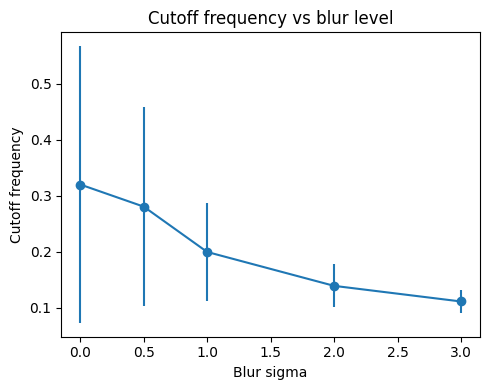

In [16]:
plt.figure(figsize=(5,4))
means = df_verif.groupby("blur_sigma")["fc"].mean()
stds = df_verif.groupby("blur_sigma")["fc"].std()
plt.errorbar(means.index, means.values, yerr=stds.values, marker='o')
plt.xlabel("Blur sigma")
plt.ylabel("Cutoff frequency")
plt.title("Cutoff frequency vs blur level")
plt.tight_layout()
plt.show()

### Does blur reduce downstream segmentation stability?

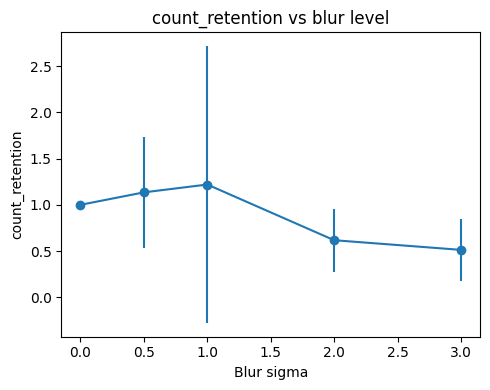

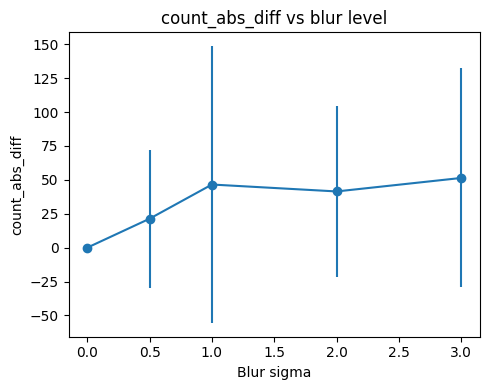

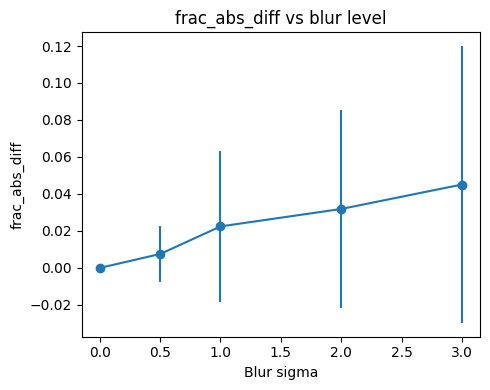

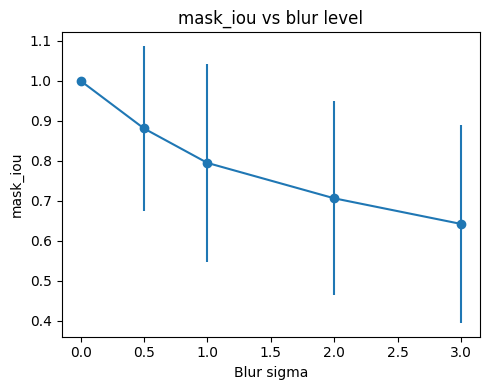

In [17]:
metrics = ["count_retention", "count_abs_diff", "frac_abs_diff", "mask_iou"]

for m in metrics:
    plt.figure(figsize=(5,4))
    means = df_verif.groupby("blur_sigma")[m].mean()
    stds = df_verif.groupby("blur_sigma")[m].std()
    plt.errorbar(means.index, means.values, yerr=stds.values, marker='o')
    plt.xlabel("Blur sigma")
    plt.ylabel(m)
    plt.title(f"{m} vs blur level")
    plt.tight_layout()
    plt.show()

### Per-patch monotonic association between cutoff ratio and downstream reliability

In [18]:
for m in ["count_retention", "mask_iou"]:
    corr_list = []
    for fname, sub in df_verif.groupby(["group", "file"]):
        if len(sub) < 3:
            continue
        sub = sub.sort_values("blur_sigma")
        if sub["fc_ratio"].std() < 1e-12 or sub[m].std() < 1e-12:
            continue
        corr = sub["fc_ratio"].corr(sub[m], method="spearman")
        corr_list.append(corr)
    print(m, np.nanmean(corr_list), np.nanmedian(corr_list), len(corr_list))

count_retention 0.8453679302937601 0.9486832980505138 15
mask_iou 0.9371343314124599 0.9873397172404481 20


### Cross-sectional exploratory plots and example patches

In [19]:
for m in ["count_retention", "count_abs_diff", "mask_iou"]:
    # corr = df_verif["fc"].corr(df_verif[m])
    for s in blur_levels:
        sub = df_verif[df_verif["blur_sigma"] == s]
        corr = sub["fc"].corr(sub[m])
        print(f"{m}: corr with fc = {corr:.3f}")

count_retention: corr with fc = -0.208
count_retention: corr with fc = 0.545
count_retention: corr with fc = 0.481
count_retention: corr with fc = 0.038
count_retention: corr with fc = 0.165
count_abs_diff: corr with fc = nan
count_abs_diff: corr with fc = 0.399
count_abs_diff: corr with fc = 0.443
count_abs_diff: corr with fc = 0.154
count_abs_diff: corr with fc = 0.201
mask_iou: corr with fc = -0.272
mask_iou: corr with fc = -0.430
mask_iou: corr with fc = -0.500
mask_iou: corr with fc = -0.557
mask_iou: corr with fc = -0.593


/home/victorh/miniconda3/envs/pytor/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/victorh/miniconda3/envs/pytor/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


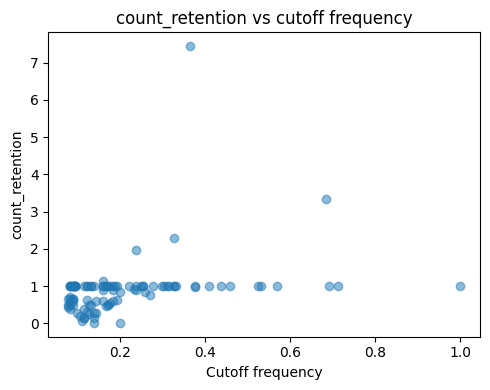

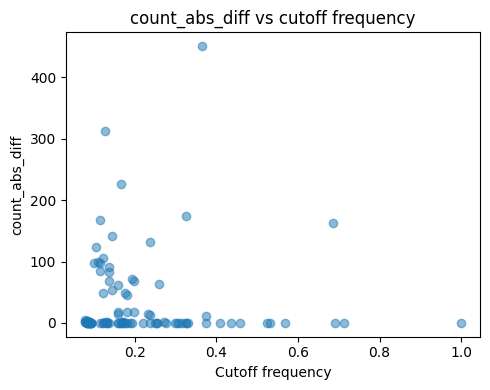

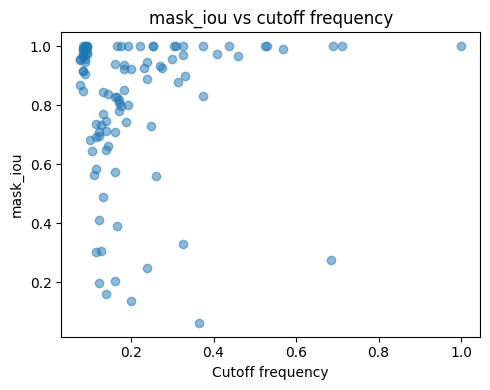

In [20]:
for m in ["count_retention", "count_abs_diff", "mask_iou"]:
    plt.figure(figsize=(5,4))
    plt.scatter(df_verif["fc"], df_verif[m], alpha=0.5)
    plt.xlabel("Cutoff frequency")
    plt.ylabel(m)
    plt.title(f"{m} vs cutoff frequency")
    plt.tight_layout()
    plt.show()

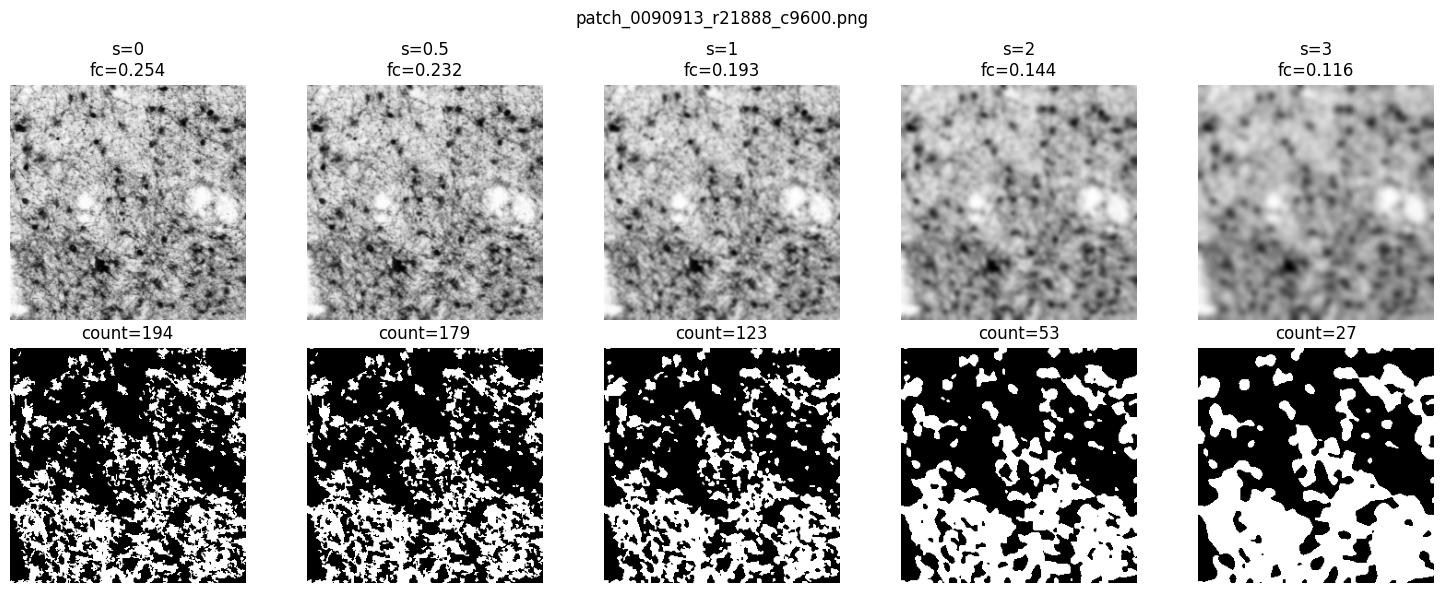

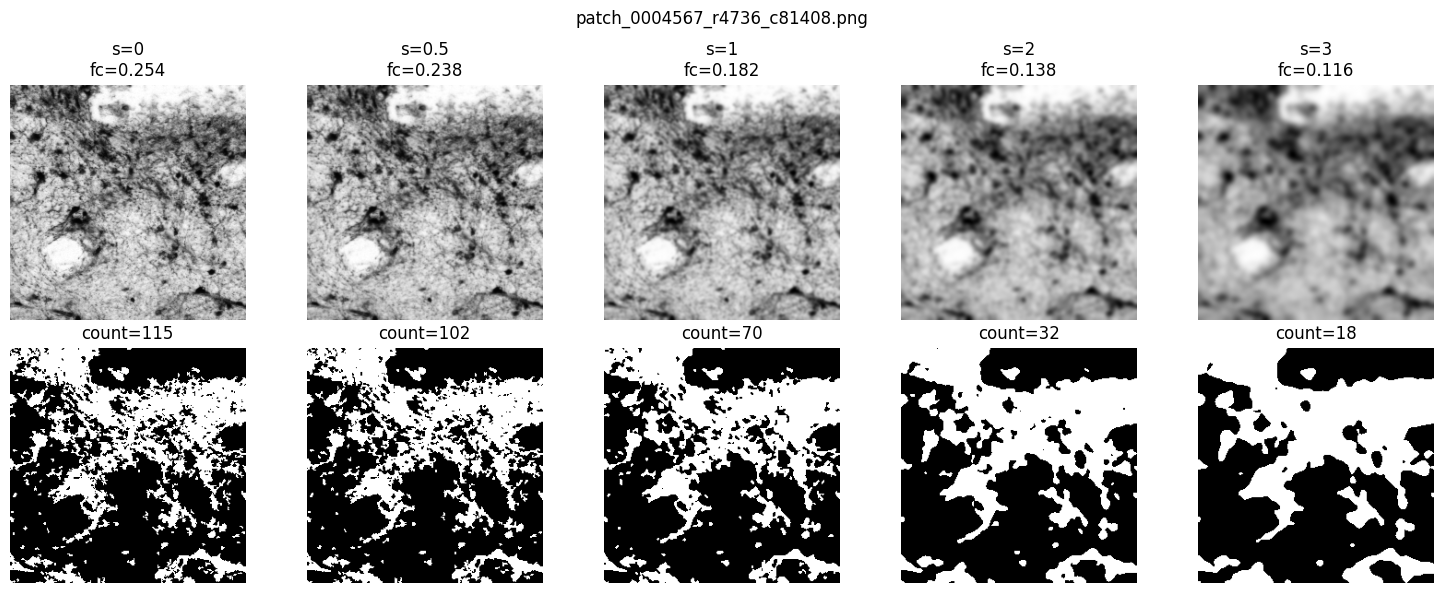

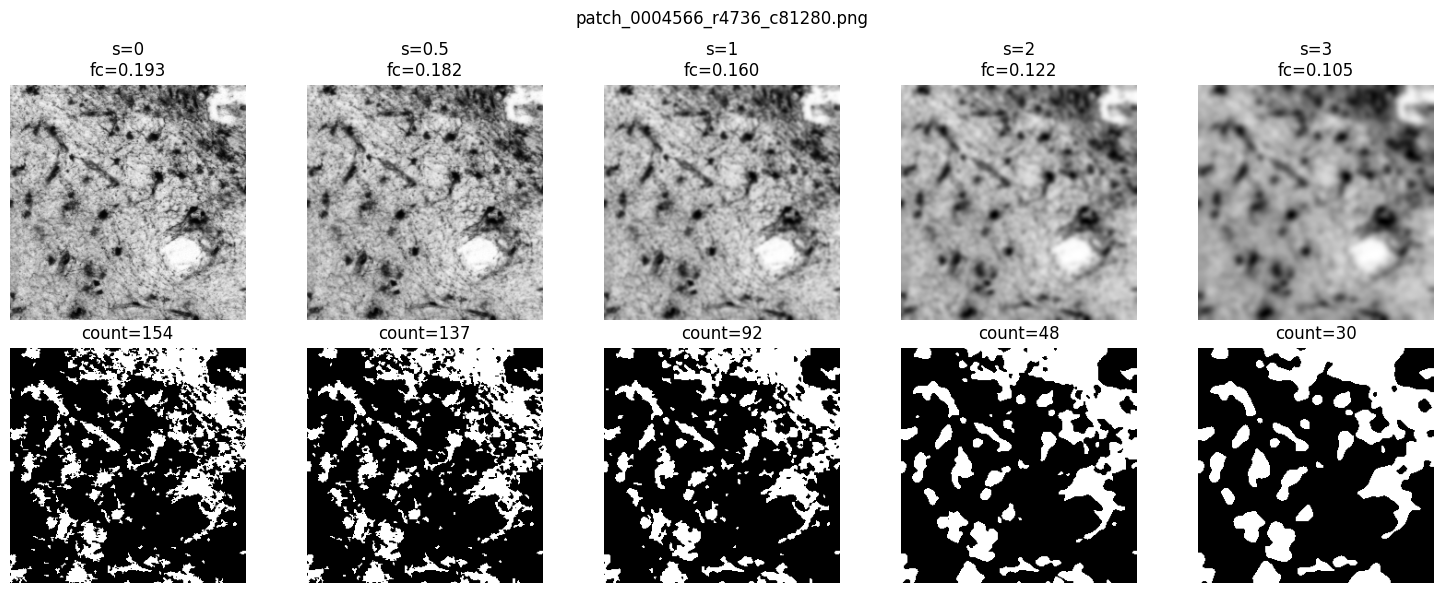

In [21]:
example_group = groups[0]
example_path = os.path.join(base, example_group)
example_files = [f for f in os.listdir(example_path) if f.endswith(".png")][:3]

for fname in example_files:
    patch = np.array(Image.open(os.path.join(example_path, fname)).convert("L"))

    fig, axes = plt.subplots(2, len(blur_levels), figsize=(3*len(blur_levels), 6))
    fig.suptitle(fname)

    for j, s in enumerate(blur_levels):
        if s > 0:
            patch_blur = gaussian_filter(patch.astype(np.float32), s)
        else:
            patch_blur = patch.astype(np.float32)

        fc_s, _, _, _ = effective_resolution_cutoff(patch_blur)
        cnt_s, frac_s, mask_s = naive_segment_count(patch_blur, blur_sigma=0.0, min_size=6, dark_objects=True)

        axes[0, j].imshow(patch_blur, cmap="gray")
        axes[0, j].set_title(f"s={s}\nfc={fc_s:.3f}")
        axes[0, j].axis("off")

        axes[1, j].imshow(mask_s, cmap="gray")
        axes[1, j].set_title(f"count={cnt_s}")
        axes[1, j].axis("off")

    plt.tight_layout()
    plt.show()


# 3. Multi-metric validation under blur and additive noise

We now compare three quality metrics under two degradation families:

- `fc`: effective spectral cutoff frequency
- `spectral_energy`: high-frequency spectral energy ratio
- `laplacian_var`: Laplacian variance as a sharpness proxy

The goal is to determine whether these metrics track a unified downstream reliability score in a consistent way.


In [22]:

NOISE_STDS = [0.0, 0.01, 0.02, 0.04, 0.06]
SPECTRAL_CUTOFF = 0.25

def spectral_energy_metric(gray, cutoff=SPECTRAL_CUTOFF):
    g = gray.astype(np.float32)
    g = g - float(np.mean(g))

    h, w = g.shape
    win = np.outer(np.hanning(h), np.hanning(w)).astype(np.float32)
    F = np.fft.fftshift(np.fft.fft2(g * win))
    P = (np.abs(F) ** 2).astype(np.float64)

    yy, xx = np.indices(P.shape)
    cy = (h - 1) / 2.0
    cx = (w - 1) / 2.0
    rr = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)
    rr_norm = rr / max(rr.max(), 1e-8)

    high = P[rr_norm >= cutoff].sum()
    total = P.sum() + 1e-12
    return float(high / total)

def laplacian_variance_metric(gray):
    lap = ndi.laplace(gray.astype(np.float32))
    return float(np.var(lap))

def add_gaussian_noise(gray, noise_std, rng):
    x = gray.astype(np.float32) / 255.0
    noisy = np.clip(x + rng.normal(0.0, float(noise_std), size=x.shape), 0.0, 1.0)
    return (255.0 * noisy).astype(np.float32)

def compute_three_quality_metrics(gray):
    fc, _, _, _ = effective_resolution_cutoff(gray)
    q_spec = spectral_energy_metric(gray)
    q_lap = laplacian_variance_metric(gray)
    return fc, q_spec, q_lap

In [23]:
rows_metric_verif = []
rng = np.random.default_rng(31)

for g in groups:
    path = os.path.join(base, g)
    for fname in os.listdir(path):
        if not fname.endswith(".png"):
            continue

        patch = np.array(Image.open(os.path.join(path, fname)).convert("L"), dtype=np.float32)

        # baseline metrics and segmentation target
        fc0, qspec0, qlap0 = compute_three_quality_metrics(patch)
        cnt0, frac0, mask0 = naive_segment_count(
            patch, blur_sigma=0.0, min_size=6, dark_objects=True
        )

        # blur degradation
        for s in blur_levels:
            if s > 0:
                degraded = gaussian_filter(patch, s)
            else:
                degraded = patch.copy()

            fc_s, qspec_s, qlap_s = compute_three_quality_metrics(degraded)
            cnt_s, frac_s, mask_s = naive_segment_count(
                degraded, blur_sigma=0.0, min_size=6, dark_objects=True
            )

            rows_metric_verif.append({
                "group": g,
                "file": fname,
                "degradation_type": "blur",
                "level": float(s),
                "fc": fc_s,
                "fc0": fc0,
                "fc_drop": fc0 - fc_s,
                "fc_ratio": fc_s / (fc0 + 1e-8),
                "spectral_energy": qspec_s,
                "spectral_energy0": qspec0,
                "spectral_energy_drop": qspec0 - qspec_s,
                "spectral_energy_ratio": qspec_s / (qspec0 + 1e-8),
                "laplacian_var": qlap_s,
                "laplacian_var0": qlap0,
                "laplacian_var_drop": qlap0 - qlap_s,
                "laplacian_var_ratio": qlap_s / (qlap0 + 1e-8),
                "count": cnt_s,
                "count0": cnt0,
                "count_diff": cnt_s - cnt0,
                "count_abs_diff": abs(cnt_s - cnt0),
                "count_retention": cnt_s / (cnt0 + 1e-8),
                "frac": frac_s,
                "frac0": frac0,
                "frac_abs_diff": abs(frac_s - frac0),
                "mask_iou": mask_iou(mask0, mask_s),
            })

        # noise degradation
        for std in NOISE_STDS:
            if std > 0:
                degraded = add_gaussian_noise(patch, std, rng=rng)
            else:
                degraded = patch.copy()

            fc_s, qspec_s, qlap_s = compute_three_quality_metrics(degraded)
            cnt_s, frac_s, mask_s = naive_segment_count(
                degraded, blur_sigma=0.0, min_size=6, dark_objects=True
            )

            rows_metric_verif.append({
                "group": g,
                "file": fname,
                "degradation_type": "noise",
                "level": float(std),
                "fc": fc_s,
                "fc0": fc0,
                "fc_drop": fc0 - fc_s,
                "fc_ratio": fc_s / (fc0 + 1e-8),
                "spectral_energy": qspec_s,
                "spectral_energy0": qspec0,
                "spectral_energy_drop": qspec0 - qspec_s,
                "spectral_energy_ratio": qspec_s / (qspec0 + 1e-8),
                "laplacian_var": qlap_s,
                "laplacian_var0": qlap0,
                "laplacian_var_drop": qlap0 - qlap_s,
                "laplacian_var_ratio": qlap_s / (qlap0 + 1e-8),
                "count": cnt_s,
                "count0": cnt0,
                "count_diff": cnt_s - cnt0,
                "count_abs_diff": abs(cnt_s - cnt0),
                "count_retention": cnt_s / (cnt0 + 1e-8),
                "frac": frac_s,
                "frac0": frac0,
                "frac_abs_diff": abs(frac_s - frac0),
                "mask_iou": mask_iou(mask0, mask_s),
            })

df_metric_verif = pd.DataFrame(rows_metric_verif)
print(df_metric_verif.shape)
df_metric_verif.head()

(200, 25)


,group,file,degradation_type,level,fc,fc0,fc_drop,fc_ratio,spectral_energy,spectral_energy0,...,laplacian_var_ratio,count,count0,count_diff,count_abs_diff,count_retention,frac,frac0,frac_abs_diff,mask_iou
0,spatial_high,patch_0090913_r21888_c9600.png,blur,0.0,0.254116,0.254116,0.000000,1.000000,1.429240e-01,0.142924,...,1.000000,194,194,0,0,1.000000,0.317139,0.317139,0.000000,1.000000
1,spatial_high,patch_0090913_r21888_c9600.png,blur,0.5,0.232019,0.254116,0.022097,0.913043,9.106621e-02,0.142924,...,0.435370,179,194,-15,15,0.922680,0.328140,0.317139,0.011002,0.926255
2,spatial_high,patch_0090913_r21888_c9600.png,blur,1.0,0.193350,0.254116,0.060767,0.760870,2.135895e-02,0.142924,...,0.071190,123,194,-71,71,0.634021,0.346588,0.317139,0.029449,0.801234
3,spatial_high,patch_0090913_r21888_c9600.png,blur,2.0,0.143631,0.254116,0.110485,0.565217,2.980908e-04,0.142924,...,0.008156,53,194,-141,141,0.273196,0.396500,0.317139,0.079361,0.662425
4,spatial_high,patch_0090913_r21888_c9600.png,blur,3.0,0.116010,0.254116,0.138107,0.456522,4.658734e-07,0.142924,...,0.001842,27,194,-167,167,0.139175,0.453659,0.317139,0.136520,0.582352


## A unified downstream reliability score.

Higher reliability_score = better downstream agreement with the original patch.

In [24]:
def _minmax01(x):
    x = x.astype(float)
    denom = x.max() - x.min()
    if denom < 1e-12:
        return pd.Series(np.zeros(len(x)), index=x.index)
    return (x - x.min()) / denom

# Normalize absolute count error within each degradation family so it can be combined
# with the other bounded downstream metrics.
df_metric_verif["count_abs_diff_norm"] = (
    df_metric_verif.groupby("degradation_type")["count_abs_diff"]
    .transform(_minmax01)
)

df_metric_verif["mask_iou_clip"] = df_metric_verif["mask_iou"].clip(0.0, 1.0)
df_metric_verif["count_retention_clip"] = df_metric_verif["count_retention"].clip(0.0, 1.0)
df_metric_verif["frac_abs_diff_clip"] = df_metric_verif["frac_abs_diff"].clip(0.0, 1.0)

df_metric_verif["reliability_score"] = (
    df_metric_verif["mask_iou_clip"]
    + df_metric_verif["count_retention_clip"]
    + (1.0 - df_metric_verif["frac_abs_diff_clip"])
    + (1.0 - df_metric_verif["count_abs_diff_norm"])
) / 4.0

summary_cols = [
    "fc_ratio",
    "spectral_energy_ratio",
    "laplacian_var_ratio",
    "count_retention",
    "count_abs_diff",
    "frac_abs_diff",
    "mask_iou",
    "reliability_score",
]

metric_validation_summary = (
    df_metric_verif
    .groupby(["degradation_type", "level"])[summary_cols]
    .agg(["mean", "std", "median"])
)

metric_validation_summary


fc_ratio                          \
                            mean           std    median   
degradation_type level                                     
blur             0.00   1.000000  3.768342e-08  1.000000   
                 0.50   0.936163  9.428160e-02  0.967708   
                 1.00   0.759054  1.919873e-01  0.774838   
                 2.00   0.600771  2.530545e-01  0.564427   
                 3.00   0.511974  2.606115e-01  0.456522   
noise            0.00   1.000000  3.768342e-08  1.000000   
                 0.01   1.282047  6.883293e-01  1.000000   
                 0.02   1.521053  8.270786e-01  1.000000   
                 0.04   1.560437  8.414330e-01  1.000000   
                 0.06   1.788913  1.230856e+00  1.012500   

                       spectral_energy_ratio                       \
                                        mean        std    median   
degradation_type level                                              
blur             0.00               0.999998   0.000003  1.000000   
                 0.50               0.605217   0.120032  0.619257   
                 1.00               0.134773   0.064143  0.135989   
                 2.00               0.002193   0.001661  0.001848   
                 3.00               0.000004   0.000004  0.000003   
noise            0.00               0.999998   0.000003  1.000000   
                 0.01               1.477508   0.499769  1.335798   
                 0.02               2.564845   1.985824  1.478513   
                 0.04               5.995953   7.472449  1.531226   
                 0.06              10.644516  15.387305  1.658267   

                       laplacian_var_ratio                           \
                                      mean           std     median   
degradation_type level                                                
blur             0.00             1.000000  1.516388e-10   1.000000   
                 0.50             0.357558  6.017210e-02   0.345587   
                 1.00             0.044961  2.603308e-02   0.044268   
                 2.00             0.006683  5.794430e-03   0.006552   
                 3.00             0.002096  2.320343e-03   0.001630   
noise            0.00             1.000000  1.516388e-10   1.000000   
                 0.01             1.790145  7.354992e-01   1.601015   
                 0.02             4.207806  2.953314e+00   3.458858   
                 0.04            13.305598  1.125243e+01  10.519137   
                 0.06            27.780093  2.471442e+01  21.695441   

                       count_retention  ... count_abs_diff frac_abs_diff  \
                                  mean  ...         median          mean   
degradation_type level                  ...                                
blur             0.00         1.000000  ...            0.0      0.000000   
                 0.50         1.134777  ...            0.0      0.007525   
                 1.00         1.219620  ...            1.0      0.022435   
                 2.00         0.617142  ...            2.0      0.031878   
                 3.00         0.512496  ...            2.5      0.045094   
noise            0.00         1.000000  ...            0.0      0.000000   
                 0.01        27.992924  ...            1.0      0.008386   
                 0.02        30.604778  ...            1.0      0.009106   
                 0.04        47.761513  ...            4.0      0.014528   
                 0.06        58.477020  ...           12.5      0.017944   

                                            mask_iou                          \
                             std    median      mean           std    median   
degradation_type level                                                         
blur             0.00   0.000000  0.000000  1.000000  1.049221e-10  1.000000   
                 0.50   0.015209  0.000832  0.880820  2.056317e-01  0.951096   
                 1.00   0.040598

In [25]:

quality_metrics = [
    ("fc_ratio", "fc"),
    ("spectral_energy_ratio", "spectral_energy"),
    ("laplacian_var_ratio", "laplacian_var"),
]

corr_rows = []
for degr in ["blur", "noise"]:
    sub_degr = df_metric_verif[df_metric_verif["degradation_type"] == degr].copy()

    for q_col, q_name in quality_metrics:
        tmp = sub_degr[[q_col, "reliability_score"]].dropna()
        if len(tmp) < 3:
            continue

        x = tmp[q_col].to_numpy(dtype=float)
        y = tmp["reliability_score"].to_numpy(dtype=float)

        pearson_r, pearson_p = stats.pearsonr(x, y)
        spearman_r, spearman_p = stats.spearmanr(x, y)

        corr_rows.append({
            "degradation_type": degr,
            "quality_metric": q_name,
            "quality_column": q_col,
            "target_metric": "reliability_score",
            "pearson_r": float(pearson_r),
            "pearson_p": float(pearson_p),
            "spearman_r": float(spearman_r),
            "spearman_p": float(spearman_p),
            "n": int(len(tmp)),
        })

corr_metric_df = pd.DataFrame(corr_rows)
corr_metric_df


,degradation_type,quality_metric,quality_column,target_metric,pearson_r,pearson_p,spearman_r,spearman_p,n
0,blur,fc,fc_ratio,reliability_score,0.579314,2.710231e-10,0.678180,9.099928e-15,100
1,blur,spectral_energy,spectral_energy_ratio,reliability_score,0.555945,1.919050e-09,0.740668,1.276737e-18,100
2,blur,laplacian_var,laplacian_var_ratio,reliability_score,0.541632,5.917722e-09,0.780578,1.023867e-21,100
3,noise,fc,fc_ratio,reliability_score,-0.536605,8.681077e-09,-0.343462,4.678795e-04,100
4,noise,spectral_energy,spectral_energy_ratio,reliability_score,0.065894,5.148119e-01,-0.500290,1.157738e-07,100
5,noise,laplacian_var,laplacian_var_ratio,reliability_score,-0.512095,5.154609e-08,-0.676018,1.189709e-14,100


In [26]:

for degr in ["blur", "noise"]:
    print(f"=== {degr.upper()} : pooled correlations against reliability_score ===")
    sub = corr_metric_df[corr_metric_df["degradation_type"] == degr].copy()
    display(
        sub[["quality_metric", "pearson_r", "spearman_r", "n"]]
        .sort_values("quality_metric")
        .round(3)
        .reset_index(drop=True)
    )

# Also compute within-level rank consistency
level_corr_rows = []
for degr in ["blur", "noise"]:
    sub_degr = df_metric_verif[df_metric_verif["degradation_type"] == degr].copy()
    for level, sub_level in sub_degr.groupby("level"):
        for q_col, q_name in quality_metrics:
            tmp = sub_level[[q_col, "reliability_score"]].dropna()
            if len(tmp) < 3:
                continue
            sr, sp = stats.spearmanr(tmp[q_col].to_numpy(dtype=float), tmp["reliability_score"].to_numpy(dtype=float))
            level_corr_rows.append({
                "degradation_type": degr,
                "level": float(level),
                "quality_metric": q_name,
                "spearman_r": float(sr),
                "spearman_p": float(sp),
                "n": int(len(tmp)),
            })

corr_by_level_df = pd.DataFrame(level_corr_rows)

corr_by_level_summary = (
    corr_by_level_df
    .groupby(["degradation_type", "quality_metric"])["spearman_r"]
    .agg(["mean", "std", "median"])
    .round(3)
)

print("=== Mean within-level Spearman correlation against reliability_score ===")
display(corr_by_level_summary)


=== BLUR : pooled correlations against reliability_score ===


,quality_metric,pearson_r,spearman_r,n
0,fc,0.579,0.678,100
1,laplacian_var,0.542,0.781,100
2,spectral_energy,0.556,0.741,100


=== NOISE : pooled correlations against reliability_score ===


,quality_metric,pearson_r,spearman_r,n
0,fc,-0.537,-0.343,100
1,laplacian_var,-0.512,-0.676,100
2,spectral_energy,0.066,-0.500,100


=== Mean within-level Spearman correlation against reliability_score ===


mean    std  median
degradation_type quality_metric                       
blur             fc               0.014  0.152   0.034
                 laplacian_var    0.195  0.164   0.164
                 spectral_energy -0.166  0.079  -0.144
noise            fc              -0.304  0.198  -0.189
                 laplacian_var   -0.151  0.359  -0.238
                 spectral_energy  0.139  0.214   0.156

## Degradation-level correlations

In [27]:
print(df_metric_verif.columns.tolist())

['group', 'file', 'degradation_type', 'level', 'fc', 'fc0', 'fc_drop', 'fc_ratio', 'spectral_energy', 'spectral_energy0', 'spectral_energy_drop', 'spectral_energy_ratio', 'laplacian_var', 'laplacian_var0', 'laplacian_var_drop', 'laplacian_var_ratio', 'count', 'count0', 'count_diff', 'count_abs_diff', 'count_retention', 'frac', 'frac0', 'frac_abs_diff', 'mask_iou', 'count_abs_diff_norm', 'mask_iou_clip', 'count_retention_clip', 'frac_abs_diff_clip', 'reliability_score']


In [28]:

quality_cols = {
    "fc": "fc_ratio",
    "spectral_energy": "spectral_energy_ratio",
    "laplacian_var": "laplacian_var_ratio",
}

rows = []

for degr, sub in df_metric_verif.groupby("degradation_type"):
    for qname, qcol in quality_cols.items():
        tmp = sub[[ "level", qcol ]].dropna()

        if len(tmp) < 3:
            continue

        pr, pp = pearsonr(tmp["level"], tmp[qcol])
        sr, sp = spearmanr(tmp["level"], tmp[qcol])

        rows.append({
            "degradation_type": degr,
            "quality_metric": qname,
            "pearson_r": pr,
            "pearson_p": pp,
            "spearman_r": sr,
            "spearman_p": sp,
            "n": len(tmp),
        })

corr_degradation_df = pd.DataFrame(rows)
corr_degradation_df

,degradation_type,quality_metric,pearson_r,pearson_p,spearman_r,spearman_p,n
0,blur,fc,-0.697555,7.417034e-16,-0.787577,2.512919e-22,100
1,blur,spectral_energy,-0.848987,6.699975e-29,-0.979845,2.310370e-70,100
2,blur,laplacian_var,-0.770353,7.285873e-21,-0.958043,5.495187e-55,100
3,noise,fc,0.296895,2.703638e-03,0.196553,4.999747e-02,100
4,noise,spectral_energy,0.424474,1.075683e-05,0.683932,4.411219e-15,100
5,noise,laplacian_var,0.625268,3.550509e-12,0.844871,2.254045e-28,100


In [29]:
pivot_table = (
    corr_degradation_df
    .pivot(index="quality_metric", columns="degradation_type", values="spearman_r")
    .round(3)
)

pivot_table

degradation_type,blur,noise
quality_metric,,
fc,-0.788,0.197
laplacian_var,-0.958,0.845
spectral_energy,-0.980,0.684


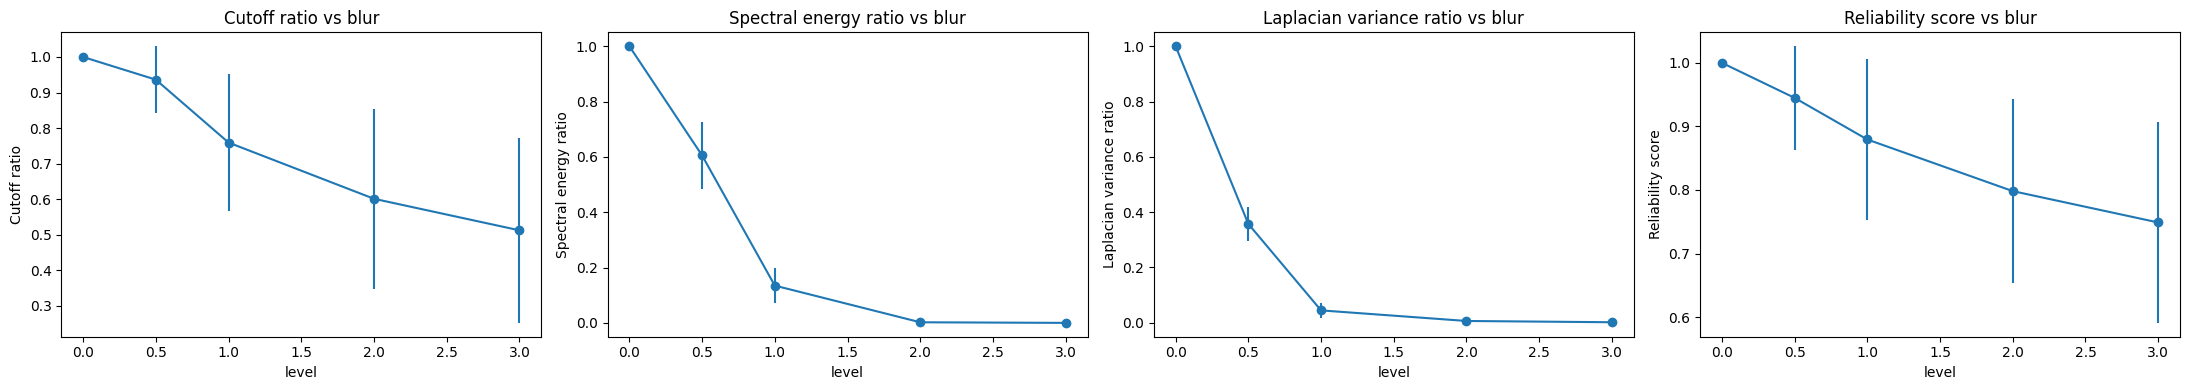

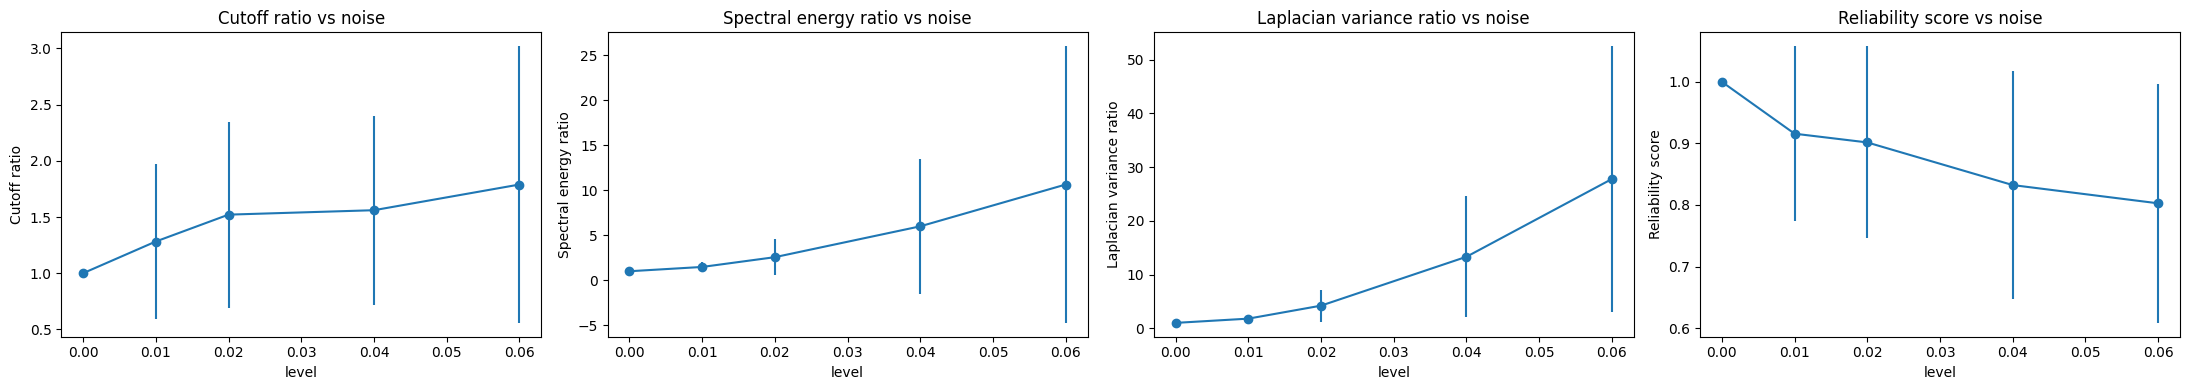

In [30]:

plot_specs = [
    ("fc_ratio", "Cutoff ratio"),
    ("spectral_energy_ratio", "Spectral energy ratio"),
    ("laplacian_var_ratio", "Laplacian variance ratio"),
    ("reliability_score", "Reliability score"),
]

for degr in ["blur", "noise"]:
    sub = df_metric_verif[df_metric_verif["degradation_type"] == degr].copy()

    fig, axes = plt.subplots(1, 4, figsize=(22, 4))
    for ax, (col, label) in zip(axes, plot_specs):
        means = sub.groupby("level")[col].mean()
        stds = sub.groupby("level")[col].std()
        ax.errorbar(means.index, means.values, yerr=stds.values, marker="o")
        ax.set_title(f"{label} vs {degr}")
        ax.set_xlabel("level")
        ax.set_ylabel(label)
    plt.tight_layout()
    plt.show()
